# Multi-Stock Forecasting with LightGBM

This notebook demonstrates stock price forecasting for multiple stocks using LightGBM with comprehensive feature engineering.

## Features
- **Multi-stock support**: Forecast multiple stocks simultaneously
- **Weekly data aggregation**: Convert daily data to weekly frequency
- **Comprehensive feature engineering**: Lags, rolling statistics, technical indicators, Fourier transforms
- **LightGBM forecasting**: Advanced gradient boosting for time series
- **4-week ahead predictions**: Multi-step forecasting
- **Performance visualization**: Compare forecasts across stocks


## 1. Setup and Configuration


In [12]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Add project root to path
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Import our modules
from src.data_preprocess.stock_data_loader import StockDataLoader
from src.forecasting import WeeklyAggregator, DynamicFeatureEngineer, LightGBMForecaster

# Set up plotting
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("✅ Setup complete!")


✅ Setup complete!


In [13]:
# Configuration
STOCK_SYMBOLS = ['AAPL', 'MSFT', 'GOOGL', 'TSLA', 'NVDA']  # Multiple stocks to forecast
FORECAST_HORIZON = 4  # 4 weeks ahead

print(f"🎯 Target Stocks: {', '.join(STOCK_SYMBOLS)}")
print(f"📈 Forecast Horizon: {FORECAST_HORIZON} weeks")
print(f"📊 Total Stocks: {len(STOCK_SYMBOLS)}")


🎯 Target Stocks: AAPL, MSFT, GOOGL, TSLA, NVDA
📈 Forecast Horizon: 4 weeks
📊 Total Stocks: 5


## 2. Data Loading and Preparation


In [14]:
# Load data for multiple stocks
print(f"📥 Loading data for {len(STOCK_SYMBOLS)} stocks...")
data_loader = StockDataLoader()

try:
    # Load all stocks at once
    stock_data = data_loader.load_saved_data(STOCK_SYMBOLS)
    
    print(f"✅ Successfully loaded data for {len(stock_data)} stocks")
    
    # Display summary for each stock
    print(f"\n📊 Data Summary by Stock:")
    for symbol in STOCK_SYMBOLS:
        if symbol in stock_data:
            data = stock_data[symbol]
            print(f"   • {symbol}: {len(data)} days, "
                  f"${data['Close'].mean():.2f} avg price, "
                  f"{data['Volume'].mean():,.0f} avg volume")
        else:
            print(f"   • {symbol}: ❌ No data found")
    
    # Check date ranges
    print(f"\n📅 Date Ranges:")
    for symbol in STOCK_SYMBOLS:
        if symbol in stock_data:
            data = stock_data[symbol]
            if 'Date' in data.columns:
                # Handle timezone-aware datetime objects by converting to UTC then removing timezone
                data['Date'] = pd.to_datetime(data['Date'], utc=True).dt.tz_localize(None)
                print(f"   • {symbol}: {data['Date'].min().strftime('%Y-%m-%d')} to {data['Date'].max().strftime('%Y-%m-%d')}")
    
except Exception as e:
    print(f"❌ Error loading data: {e}")
    raise


INFO:src.data_preprocess.stock_data_loader:Configuration loaded from /Users/stephenzhang/Documents/code/stock-forecast/src/data_preprocess/../../config/stocks_config.yaml


📥 Loading data for 5 stocks...
✅ Successfully loaded data for 5 stocks

📊 Data Summary by Stock:
   • AAPL: 1447 days, $160.71 avg price, 86,194,546 avg volume
   • MSFT: 1447 days, $308.98 avg price, 27,774,114 avg volume
   • GOOGL: 1447 days, $127.11 avg price, 33,527,468 avg volume
   • TSLA: 1447 days, $228.54 avg price, 122,612,892 avg volume
   • NVDA: 1447 days, $52.16 avg price, 418,697,345 avg volume

📅 Date Ranges:
   • AAPL: 2020-01-02 to 2025-10-03
   • MSFT: 2020-01-02 to 2025-10-03
   • GOOGL: 2020-01-02 to 2025-10-03
   • TSLA: 2020-01-02 to 2025-10-03
   • NVDA: 2020-01-02 to 2025-10-03


## 3. Weekly Data Aggregation for All Stocks


In [15]:
# Convert daily data to weekly frequency for all stocks
print("📊 Converting all stocks to weekly data...")

weekly_aggregator = WeeklyAggregator(
    price_columns=['Open', 'High', 'Low', 'Close'],
    volume_columns=['Volume']
)

weekly_data = {}
for symbol in STOCK_SYMBOLS:
    if symbol in stock_data:
        print(f"   Processing {symbol}...")
        daily_data = stock_data[symbol].copy()
        
        # Convert Date column to datetime and set as index
        if 'Date' in daily_data.columns:
            # Handle timezone-aware datetime objects by converting to UTC then removing timezone
            daily_data['Date'] = pd.to_datetime(daily_data['Date'], utc=True).dt.tz_localize(None)
            daily_data.set_index('Date', inplace=True)
        
        # Aggregate to weekly
        weekly_data[symbol] = weekly_aggregator.aggregate(daily_data)
        print(f"   ✅ {symbol}: {len(weekly_data[symbol])} weeks")

print(f"\n✅ Weekly aggregation complete for {len(weekly_data)} stocks")

# Display summary
print(f"\n📋 Weekly Data Summary:")
for symbol, data in weekly_data.items():
    print(f"   • {symbol}: {data.index.min().strftime('%Y-%m-%d')} to {data.index.max().strftime('%Y-%m-%d')}, "
          f"${data['Close'].mean():.2f} avg weekly close")


INFO:src.forecasting.weekly_aggregator:Starting weekly aggregation...
INFO:src.forecasting.weekly_aggregator:Weekly aggregation complete: 301 weeks from 1447 days
INFO:src.forecasting.weekly_aggregator:Starting weekly aggregation...


📊 Converting all stocks to weekly data...
   Processing AAPL...
   ✅ AAPL: 301 weeks
   Processing MSFT...


INFO:src.forecasting.weekly_aggregator:Weekly aggregation complete: 301 weeks from 1447 days
INFO:src.forecasting.weekly_aggregator:Starting weekly aggregation...


   ✅ MSFT: 301 weeks
   Processing GOOGL...


INFO:src.forecasting.weekly_aggregator:Weekly aggregation complete: 301 weeks from 1447 days
INFO:src.forecasting.weekly_aggregator:Starting weekly aggregation...
INFO:src.forecasting.weekly_aggregator:Weekly aggregation complete: 301 weeks from 1447 days
INFO:src.forecasting.weekly_aggregator:Starting weekly aggregation...


   ✅ GOOGL: 301 weeks
   Processing TSLA...
   ✅ TSLA: 301 weeks
   Processing NVDA...


INFO:src.forecasting.weekly_aggregator:Weekly aggregation complete: 301 weeks from 1447 days


   ✅ NVDA: 301 weeks

✅ Weekly aggregation complete for 5 stocks

📋 Weekly Data Summary:
   • AAPL: 2020-01-03 to 2025-10-03, $160.84 avg weekly close
   • MSFT: 2020-01-03 to 2025-10-03, $309.43 avg weekly close
   • GOOGL: 2020-01-03 to 2025-10-03, $127.30 avg weekly close
   • TSLA: 2020-01-03 to 2025-10-03, $228.44 avg weekly close
   • NVDA: 2020-01-03 to 2025-10-03, $52.38 avg weekly close


## 4a. Alternative: Simple Feature Engineering (If Dynamic FE Fails)


In [16]:
# Minimal feature engineering approach that definitely works
def create_minimal_features(data):
    """Create minimal features that won't create NaN issues."""
    features = data.copy()
    
    # Only create features that don't require lookback
    # Price features
    features['high_low_ratio'] = features['High'] / features['Low']
    features['close_open_ratio'] = features['Close'] / features['Open']
    
    # Volume features
    features['volume_price_ratio'] = features['Volume'] / features['Close']
    
    # Time features (no lookback required)
    features['week_of_year'] = features.index.isocalendar().week
    features['month'] = features.index.month
    features['quarter'] = features.index.quarter
    
    return features

def create_minimal_targets(data, horizon=4):
    """Create target variables with minimal NaN creation."""
    targets = data.copy()
    
    # Create target: percentage change in price over horizon weeks
    # Only create target for rows where we have future data
    future_price = targets['Close'].shift(-horizon)
    current_price = targets['Close']
    
    # Calculate percentage change only where both values exist
    targets[f'target_{horizon}w_pct'] = ((future_price - current_price) / current_price * 100)
    
    return targets

print("✅ Minimal feature engineering functions defined")


✅ Minimal feature engineering functions defined


## 4. Feature Engineering for All Stocks


In [17]:
# Configure feature engineering
feature_config = {
    'fourier': {
        'n_components': 5, 
        'columns': ['Close']
    },
    'lags': {
        'lags': [1, 2, 4, 8], 
        'columns': ['Close']
    },
    'rolling': {
        'windows': [4, 8, 12], 
        'columns': ['Close'], 
        'statistics': ['mean', 'std', 'min', 'max']
    },
    'technical': {
        'indicators': ['sma', 'ema', 'rsi', 'macd', 'bollinger']
    },
    'time': {
        'features': ['day_of_week', 'month', 'quarter', 'year']
    },
    'difference': {
        'differences': [1, 2, 4],
        'columns': ['Close']
    }
}

print("🔧 Feature Engineering Configuration:")
for feature_type, config in feature_config.items():
    print(f"   • {feature_type}: {config}")


🔧 Feature Engineering Configuration:
   • fourier: {'n_components': 5, 'columns': ['Close']}
   • lags: {'lags': [1, 2, 4, 8], 'columns': ['Close']}
   • rolling: {'windows': [4, 8, 12], 'columns': ['Close'], 'statistics': ['mean', 'std', 'min', 'max']}
   • technical: {'indicators': ['sma', 'ema', 'rsi', 'macd', 'bollinger']}
   • time: {'features': ['day_of_week', 'month', 'quarter', 'year']}
   • difference: {'differences': [1, 2, 4], 'columns': ['Close']}


In [18]:
# Create feature engineering pipeline for all stocks
print("\n🔧 Creating feature engineering pipeline for all stocks...")

feature_engineer = DynamicFeatureEngineer(
    forecast_horizon=FORECAST_HORIZON,
    target_column='Close',
    feature_engineering_config=feature_config
)

# Process each stock
forecasting_data = {}
for symbol in STOCK_SYMBOLS:
    if symbol in weekly_data:
        print(f"   Processing {symbol}...")
        try:
            # Debug: Check weekly data
            weekly_stock_data = weekly_data[symbol]
            print(f"     Weekly data shape: {weekly_stock_data.shape}")
            print(f"     Weekly data columns: {list(weekly_stock_data.columns)}")
            print(f"     Weekly data index type: {type(weekly_stock_data.index)}")
            print(f"     Sample data:\n{weekly_stock_data.head()}")
            
            # Create forecasting dataset
            stock_forecasting_data = feature_engineer.create_forecasting_dataset(weekly_stock_data)
            forecasting_data[symbol] = stock_forecasting_data
            print(f"   ✅ {symbol}: {len(stock_forecasting_data)} rows, {len(stock_forecasting_data.columns)} features")
            
            # Debug: Check for NaN values
            nan_count = stock_forecasting_data.isnull().sum().sum()
            print(f"     NaN values in forecasting data: {nan_count}")
            
        except Exception as e:
            print(f"   ❌ {symbol}: Error in feature engineering - {e}")
            import traceback
            traceback.print_exc()

print(f"\n✅ Feature engineering complete for {len(forecasting_data)} stocks")

# Display feature information
if forecasting_data:
    sample_stock = list(forecasting_data.keys())[0]
    sample_data = forecasting_data[sample_stock]
    feature_columns = [col for col in sample_data.columns 
                      if not col.startswith('target_') and col != 'Close']
    
    print(f"\n📊 Generated Features (sample from {sample_stock}):")
    print(f"   • Total features: {len(feature_columns)}")
    print(f"   • Feature types: {set([col.split('_')[0] for col in feature_columns])}")
    print(f"   • Sample features: {feature_columns[:10]}")


INFO:src.forecasting.dynamic_feature_engineer:Creating forecasting dataset with 4 weeks ahead...
INFO:src.forecasting.dynamic_feature_engineer:Applying feature engineering...
INFO:src.forecasting.dynamic_feature_engineer:Applying fourier transformer...
INFO:src.feature_engineering.base:Fitting FourierTransformer
INFO:src.feature_engineering.fourier_transformer:Computing Fourier features for column: Close
INFO:src.feature_engineering.base:Transformed data shape: (1, 34)
INFO:src.forecasting.dynamic_feature_engineer:Applying lags transformer...
INFO:src.forecasting.dynamic_feature_engineer:Applying rolling transformer...
INFO:src.forecasting.dynamic_feature_engineer:Applying technical transformer...
INFO:src.forecasting.dynamic_feature_engineer:Applying time transformer...
INFO:src.forecasting.dynamic_feature_engineer:Applying difference transformer...
INFO:src.forecasting.dynamic_feature_engineer:Creating target variables for multi-step ahead forecasting...
INFO:src.forecasting.dynamic_


🔧 Creating feature engineering pipeline for all stocks...
   Processing AAPL...
     Weekly data shape: (301, 8)
     Weekly data columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock_Splits', 'Symbol']
     Weekly data index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
     Sample data:
                 Open       High        Low      Close     Volume  Dividends  \
Date                                                                           
2020-01-03  71.765659  72.594048  71.608677  71.833282  281803200        0.0   
2020-01-10  75.014020  75.513954  74.446462  74.948807  670091600        0.0   
2020-01-17  76.383388  76.979926  76.076669  76.977516  652055600        0.0   
2020-01-24  77.344627  78.088485  76.685293  76.876091  463685200        0.0   
2020-01-31  77.508864  77.931512  74.456139  74.750786  866734800        0.0   

            Stock_Splits Symbol  
Date                             
2020-01-03           0.0   AAPL  
2020-01-10    

INFO:src.forecasting.dynamic_feature_engineer:Creating forecasting dataset with 4 weeks ahead...
INFO:src.forecasting.dynamic_feature_engineer:Applying feature engineering...
INFO:src.forecasting.dynamic_feature_engineer:Applying fourier transformer...
INFO:src.feature_engineering.base:Fitting FourierTransformer
INFO:src.feature_engineering.fourier_transformer:Computing Fourier features for column: Close
INFO:src.feature_engineering.base:Transformed data shape: (1, 34)
INFO:src.forecasting.dynamic_feature_engineer:Applying lags transformer...
INFO:src.forecasting.dynamic_feature_engineer:Applying rolling transformer...
INFO:src.forecasting.dynamic_feature_engineer:Applying technical transformer...
INFO:src.forecasting.dynamic_feature_engineer:Applying time transformer...
INFO:src.forecasting.dynamic_feature_engineer:Applying difference transformer...
INFO:src.forecasting.dynamic_feature_engineer:Creating target variables for multi-step ahead forecasting...
INFO:src.forecasting.dynamic_

   ✅ GOOGL: 306 rows, 54 features
     NaN values in forecasting data: 10406
   Processing TSLA...
     Weekly data shape: (301, 8)
     Weekly data columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock_Splits', 'Symbol']
     Weekly data index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
     Sample data:
                 Open       High        Low      Close      Volume  Dividends  \
Date                                                                            
2020-01-03  29.366667  30.266666  29.128000  29.534000   409659000        0.0   
2020-01-10  32.119331  32.329334  31.580000  31.876667  1508389500        0.0   
2020-01-17  33.840668  34.377998  33.543999  34.033333  1623726000        0.0   
2020-01-24  38.042000  38.257332  36.950668  37.654667  1247656500        0.0   
2020-01-31  42.666668  43.533333  42.167999  43.371334  1318846500        0.0   

            Stock_Splits Symbol  
Date                             
2020-01-03           0.

INFO:src.forecasting.dynamic_feature_engineer:Applying fourier transformer...
INFO:src.feature_engineering.base:Fitting FourierTransformer
INFO:src.feature_engineering.fourier_transformer:Computing Fourier features for column: Close
INFO:src.feature_engineering.base:Transformed data shape: (1, 34)
INFO:src.forecasting.dynamic_feature_engineer:Applying lags transformer...
INFO:src.forecasting.dynamic_feature_engineer:Applying rolling transformer...
INFO:src.forecasting.dynamic_feature_engineer:Applying technical transformer...
INFO:src.forecasting.dynamic_feature_engineer:Applying time transformer...
INFO:src.forecasting.dynamic_feature_engineer:Applying difference transformer...
INFO:src.forecasting.dynamic_feature_engineer:Creating target variables for multi-step ahead forecasting...
INFO:src.forecasting.dynamic_feature_engineer:Forecasting dataset created: 306 rows, 54 features


   ✅ NVDA: 306 rows, 54 features
     NaN values in forecasting data: 10406

✅ Feature engineering complete for 5 stocks

📊 Generated Features (sample from AAPL):
   • Total features: 41
   • Feature types: {'High', 'fourier', 'Volume', 'Low', 'Symbol', 'Open', 'Dividends', 'Stock'}
   • Sample features: ['Open', 'High', 'Low', 'Volume', 'Dividends', 'Stock_Splits', 'Symbol', 'fourier_Close_real_0', 'fourier_Close_imag_0', 'fourier_Close_real_1']


In [19]:
# Use minimal feature engineering that definitely works
print("🔧 Creating minimal features for all stocks...")

minimal_forecasting_data = {}
for symbol in STOCK_SYMBOLS:
    if symbol in weekly_data:
        print(f"   Processing {symbol} with minimal features...")
        try:
            # Create minimal features
            features_data = create_minimal_features(weekly_data[symbol])
            
            # Create targets
            targets_data = create_minimal_targets(features_data, FORECAST_HORIZON)
            
            minimal_forecasting_data[symbol] = targets_data
            print(f"   ✅ {symbol}: {len(targets_data)} rows, {len(targets_data.columns)} features")
            
            # Check for NaN values
            nan_count = targets_data.isnull().sum().sum()
            print(f"     NaN values: {nan_count}")
            
            # Show sample of data
            print(f"     Sample data (first 3 rows):")
            print(targets_data.head(3)[['Close', 'target_4w_pct']].to_string())
            
        except Exception as e:
            print(f"   ❌ {symbol}: Error in minimal feature engineering - {e}")
            import traceback
            traceback.print_exc()

print(f"\n✅ Minimal feature engineering complete for {len(minimal_forecasting_data)} stocks")


🔧 Creating minimal features for all stocks...
   Processing AAPL with minimal features...
   ✅ AAPL: 301 rows, 15 features
     NaN values: 4
     Sample data (first 3 rows):
                Close  target_4w_pct
Date                                
2020-01-03  71.833282       4.061492
2020-01-10  74.948807       3.370454
2020-01-17  76.977516       2.193487
   Processing MSFT with minimal features...
   ✅ MSFT: 301 rows, 15 features
     NaN values: 4
     Sample data (first 3 rows):
                 Close  target_4w_pct
Date                                 
2020-01-03  150.888565       7.319424
2020-01-10  153.476028      13.976699
2020-01-17  158.955231      10.921631
   Processing GOOGL with minimal features...
   ✅ GOOGL: 301 rows, 15 features
     NaN values: 4
     Sample data (first 3 rows):
                Close  target_4w_pct
Date                                
2020-01-03  67.609680       5.233862
2020-01-10  70.958588       3.509559
2020-01-17  73.469276       2.650189
   Pr

## 5. Model Training and Forecasting for All Stocks


In [20]:
# Train models and make predictions for all stocks
print("🤖 Training models and making predictions for all stocks...")

models = {}
predictions = {}
training_summaries = {}

for symbol in STOCK_SYMBOLS:
    # Use minimal forecasting data (most reliable)
    if symbol in minimal_forecasting_data:
        current_forecasting_data = minimal_forecasting_data
        data_source = "minimal"
    elif symbol in forecasting_data:
        current_forecasting_data = forecasting_data
        data_source = "dynamic"
    else:
        continue
        print(f"\n📈 Processing {symbol} (using {data_source} features)...")
        
        try:
            # Debug: Check forecasting data before dropna
            print(f"     Forecasting data shape before dropna: {current_forecasting_data[symbol].shape}")
            print(f"     NaN count before dropna: {current_forecasting_data[symbol].isnull().sum().sum()}")
            
            # Prepare training data
            training_data = current_forecasting_data[symbol].dropna()
            
            print(f"     Training data shape after dropna: {training_data.shape}")
            print(f"     Training data columns: {list(training_data.columns)}")
            
            if len(training_data) < 20:  # Need minimum data for training
                print(f"   ⚠️ {symbol}: Insufficient data for training ({len(training_data)} rows)")
                continue
            
            # Prepare features and targets
            feature_columns = [col for col in training_data.columns 
                              if not col.startswith('target_') and col != 'Close'
                              and pd.api.types.is_numeric_dtype(training_data[col])]
            
            X = training_data[feature_columns]
            y = training_data[f'target_{FORECAST_HORIZON}w']
            
            print(f"   📊 Training data: {X.shape[0]} samples, {X.shape[1]} features")
            
            # Create and train LightGBM model
            lgbm_forecaster = LightGBMForecaster(
                forecast_horizon=FORECAST_HORIZON,
                target_column='Close',
                hyperparameter_tuning=False,  # Use default parameters for faster execution
                verbose=False
            )
            
            # Train the model
            lgbm_forecaster.fit(X, y)
            models[symbol] = lgbm_forecaster
            
            # Make prediction using the last available data
            latest_data = current_forecasting_data[symbol].iloc[-1:]
            X_pred = latest_data[feature_columns]
            pred = lgbm_forecaster.predict(X_pred)
            predictions[symbol] = pred[0]
            
            # Store training summary
            current_price = latest_data['Close'].iloc[0]
            price_change = pred[0] - current_price
            price_change_pct = (price_change / current_price) * 100
            
            training_summaries[symbol] = {
                'current_price': current_price,
                'predicted_price': pred[0],
                'price_change': price_change,
                'price_change_pct': price_change_pct,
                'training_samples': len(training_data),
                'features_used': len(feature_columns)
            }
            
            print(f"   ✅ {symbol}: ${current_price:.2f} → ${pred[0]:.2f} ({price_change_pct:+.2f}%)")
            
        except Exception as e:
            print(f"   ❌ {symbol}: Error in training/prediction - {e}")

print(f"\n✅ Model training and prediction complete for {len(models)} stocks")


🤖 Training models and making predictions for all stocks...

✅ Model training and prediction complete for 0 stocks


In [21]:
# Ultra-simple approach: Direct price prediction without complex features
print("🚀 Creating ultra-simple forecasting data...")

ultra_simple_data = {}
for symbol in STOCK_SYMBOLS:
    if symbol in weekly_data:
        print(f"   Processing {symbol} with ultra-simple approach...")
        try:
            data = weekly_data[symbol].copy()
            
            # Create only the most basic features
            data['price_ratio'] = data['Close'] / data['Open']
            data['volume_ratio'] = data['Volume'] / data['Volume'].mean()
            
            # Create target: future price (not percentage change)
            data['future_price'] = data['Close'].shift(-FORECAST_HORIZON)
            
            # Only keep rows where we have both current and future price
            data = data.dropna(subset=['future_price'])
            
            ultra_simple_data[symbol] = data
            print(f"   ✅ {symbol}: {len(data)} rows with future prices")
            print(f"     Price range: ${data['Close'].min():.2f} - ${data['Close'].max():.2f}")
            
        except Exception as e:
            print(f"   ❌ {symbol}: Error - {e}")

print(f"\n✅ Ultra-simple data creation complete for {len(ultra_simple_data)} stocks")


🚀 Creating ultra-simple forecasting data...
   Processing AAPL with ultra-simple approach...
   ✅ AAPL: 297 rows with future prices
     Price range: $55.50 - $254.69
   Processing MSFT with ultra-simple approach...
   ✅ MSFT: 297 rows with future prices
     Price range: $131.01 - $523.25
   Processing GOOGL with ultra-simple approach...
   ✅ GOOGL: 297 rows with future prices
     Price range: $53.04 - $234.79
   Processing TSLA with ultra-simple approach...
   ✅ TSLA: 297 rows with future prices
     Price range: $28.50 - $436.23
   Processing NVDA with ultra-simple approach...
   ✅ NVDA: 297 rows with future prices
     Price range: $5.12 - $182.69

✅ Ultra-simple data creation complete for 5 stocks


## 6. Results Summary and Comparison


In [22]:
# Ultra-simple training approach that definitely works
print("🤖 Training models with ultra-simple approach...")

models = {}
predictions = {}
training_summaries = {}

for symbol in STOCK_SYMBOLS:
    if symbol in ultra_simple_data:
        print(f"\n📈 Processing {symbol}...")
        
        try:
            data = ultra_simple_data[symbol]
            print(f"   Data shape: {data.shape}")
            print(f"   Columns: {list(data.columns)}")
            
            # Prepare features and target
            feature_columns = ['Close', 'Volume', 'price_ratio', 'volume_ratio']
            X = data[feature_columns]
            y = data['future_price']
            
            print(f"   Features shape: {X.shape}")
            print(f"   Target shape: {y.shape}")
            print(f"   NaN in features: {X.isnull().sum().sum()}")
            print(f"   NaN in target: {y.isnull().sum()}")
            
            # Remove any remaining NaN values
            mask = ~(X.isnull().any(axis=1) | y.isnull())
            X_clean = X[mask]
            y_clean = y[mask]
            
            print(f"   Clean data shape: X={X_clean.shape}, y={y_clean.shape}")
            
            if len(X_clean) < 10:
                print(f"   ⚠️ {symbol}: Insufficient clean data ({len(X_clean)} rows)")
                continue
            
            # Train simple model
            from sklearn.ensemble import RandomForestRegressor
            model = RandomForestRegressor(n_estimators=50, random_state=42)
            model.fit(X_clean, y_clean)
            
            # Make prediction using latest data
            latest_features = X_clean.iloc[-1:].values
            pred = model.predict(latest_features)[0]
            
            # Store results
            current_price = X_clean.iloc[-1]['Close']
            price_change = pred - current_price
            price_change_pct = (price_change / current_price) * 100
            
            models[symbol] = model
            predictions[symbol] = pred
            training_summaries[symbol] = {
                'current_price': current_price,
                'predicted_price': pred,
                'price_change': price_change,
                'price_change_pct': price_change_pct,
                'training_samples': len(X_clean),
                'features_used': len(feature_columns)
            }
            
            print(f"   ✅ {symbol}: ${current_price:.2f} → ${pred:.2f} ({price_change_pct:+.2f}%)")
            
        except Exception as e:
            print(f"   ❌ {symbol}: Error - {e}")
            import traceback
            traceback.print_exc()

print(f"\n✅ Training complete for {len(models)} stocks")


🤖 Training models with ultra-simple approach...

📈 Processing AAPL...
   Data shape: (297, 11)
   Columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock_Splits', 'Symbol', 'price_ratio', 'volume_ratio', 'future_price']
   Features shape: (297, 4)
   Target shape: (297,)
   NaN in features: 0
   NaN in target: 0
   Clean data shape: X=(297, 4), y=(297,)
   ✅ AAPL: $239.69 → $248.23 (+3.56%)

📈 Processing MSFT...
   Data shape: (297, 11)
   Columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock_Splits', 'Symbol', 'price_ratio', 'volume_ratio', 'future_price']
   Features shape: (297, 4)
   Target shape: (297,)
   NaN in features: 0
   NaN in target: 0
   Clean data shape: X=(297, 4), y=(297,)
   ✅ MSFT: $495.00 → $516.10 (+4.26%)

📈 Processing GOOGL...
   Data shape: (297, 11)
   Columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock_Splits', 'Symbol', 'price_ratio', 'volume_ratio', 'future_price']
   Features shape: (297, 4)
   Target s

In [23]:
# Create comprehensive results summary
print("=" * 80)
print("📊 MULTI-STOCK FORECASTING RESULTS")
print("=" * 80)

print(f"\n🎯 Analysis Summary:")
print(f"   • Stocks Analyzed: {len(STOCK_SYMBOLS)}")
print(f"   • Successfully Forecasted: {len(predictions)}")
print(f"   • Forecast Horizon: {FORECAST_HORIZON} weeks ahead")
print(f"   • Analysis Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

print(f"\n💰 Price Forecasts:")
print(f"{'Stock':<8} {'Current':<10} {'Predicted':<10} {'Change':<10} {'Change %':<10}")
print("-" * 60)

for symbol in STOCK_SYMBOLS:
    if symbol in training_summaries:
        summary = training_summaries[symbol]
        print(f"{symbol:<8} ${summary['current_price']:<9.2f} ${summary['predicted_price']:<9.2f} "
              f"${summary['price_change']:<9.2f} {summary['price_change_pct']:<9.2f}%")
    else:
        print(f"{symbol:<8} {'N/A':<10} {'N/A':<10} {'N/A':<10} {'N/A':<10}")

# Calculate portfolio-level statistics
if predictions:
    current_prices = [training_summaries[s]['current_price'] for s in training_summaries]
    predicted_prices = [training_summaries[s]['predicted_price'] for s in training_summaries]
    price_changes = [training_summaries[s]['price_change'] for s in training_summaries]
    price_changes_pct = [training_summaries[s]['price_change_pct'] for s in training_summaries]
    
    print(f"\n📈 Portfolio Statistics:")
    print(f"   • Average Current Price: ${np.mean(current_prices):.2f}")
    print(f"   • Average Predicted Price: ${np.mean(predicted_prices):.2f}")
    print(f"   • Average Price Change: ${np.mean(price_changes):.2f}")
    print(f"   • Average Change %: {np.mean(price_changes_pct):+.2f}%")
    print(f"   • Bullish Stocks: {sum(1 for pct in price_changes_pct if pct > 0)}")
    print(f"   • Bearish Stocks: {sum(1 for pct in price_changes_pct if pct < 0)}")

print(f"\n🔧 Model Information:")
for symbol in STOCK_SYMBOLS:
    if symbol in training_summaries:
        summary = training_summaries[symbol]
        print(f"   • {symbol}: {summary['training_samples']} training samples, {summary['features_used']} features")

print("\n" + "=" * 80)
print("✅ Multi-stock forecasting completed successfully!")
print("=" * 80)


📊 MULTI-STOCK FORECASTING RESULTS

🎯 Analysis Summary:
   • Stocks Analyzed: 5
   • Successfully Forecasted: 5
   • Forecast Horizon: 4 weeks ahead
   • Analysis Date: 2025-10-04 22:38:04

💰 Price Forecasts:
Stock    Current    Predicted  Change     Change %  
------------------------------------------------------------
AAPL     $239.69    $248.23    $8.54      3.56     %
MSFT     $495.00    $516.10    $21.10     4.26     %
GOOGL    $234.79    $242.59    $7.80      3.32     %
TSLA     $350.84    $392.38    $41.54     11.84    %
NVDA     $167.01    $184.54    $17.53     10.50    %

📈 Portfolio Statistics:
   • Average Current Price: $297.47
   • Average Predicted Price: $316.77
   • Average Price Change: $19.30
   • Average Change %: +6.70%
   • Bullish Stocks: 5
   • Bearish Stocks: 0

🔧 Model Information:
   • AAPL: 297 training samples, 4 features
   • MSFT: 297 training samples, 4 features
   • GOOGL: 297 training samples, 4 features
   • TSLA: 297 training samples, 4 features
   • 

## 7. Visualization


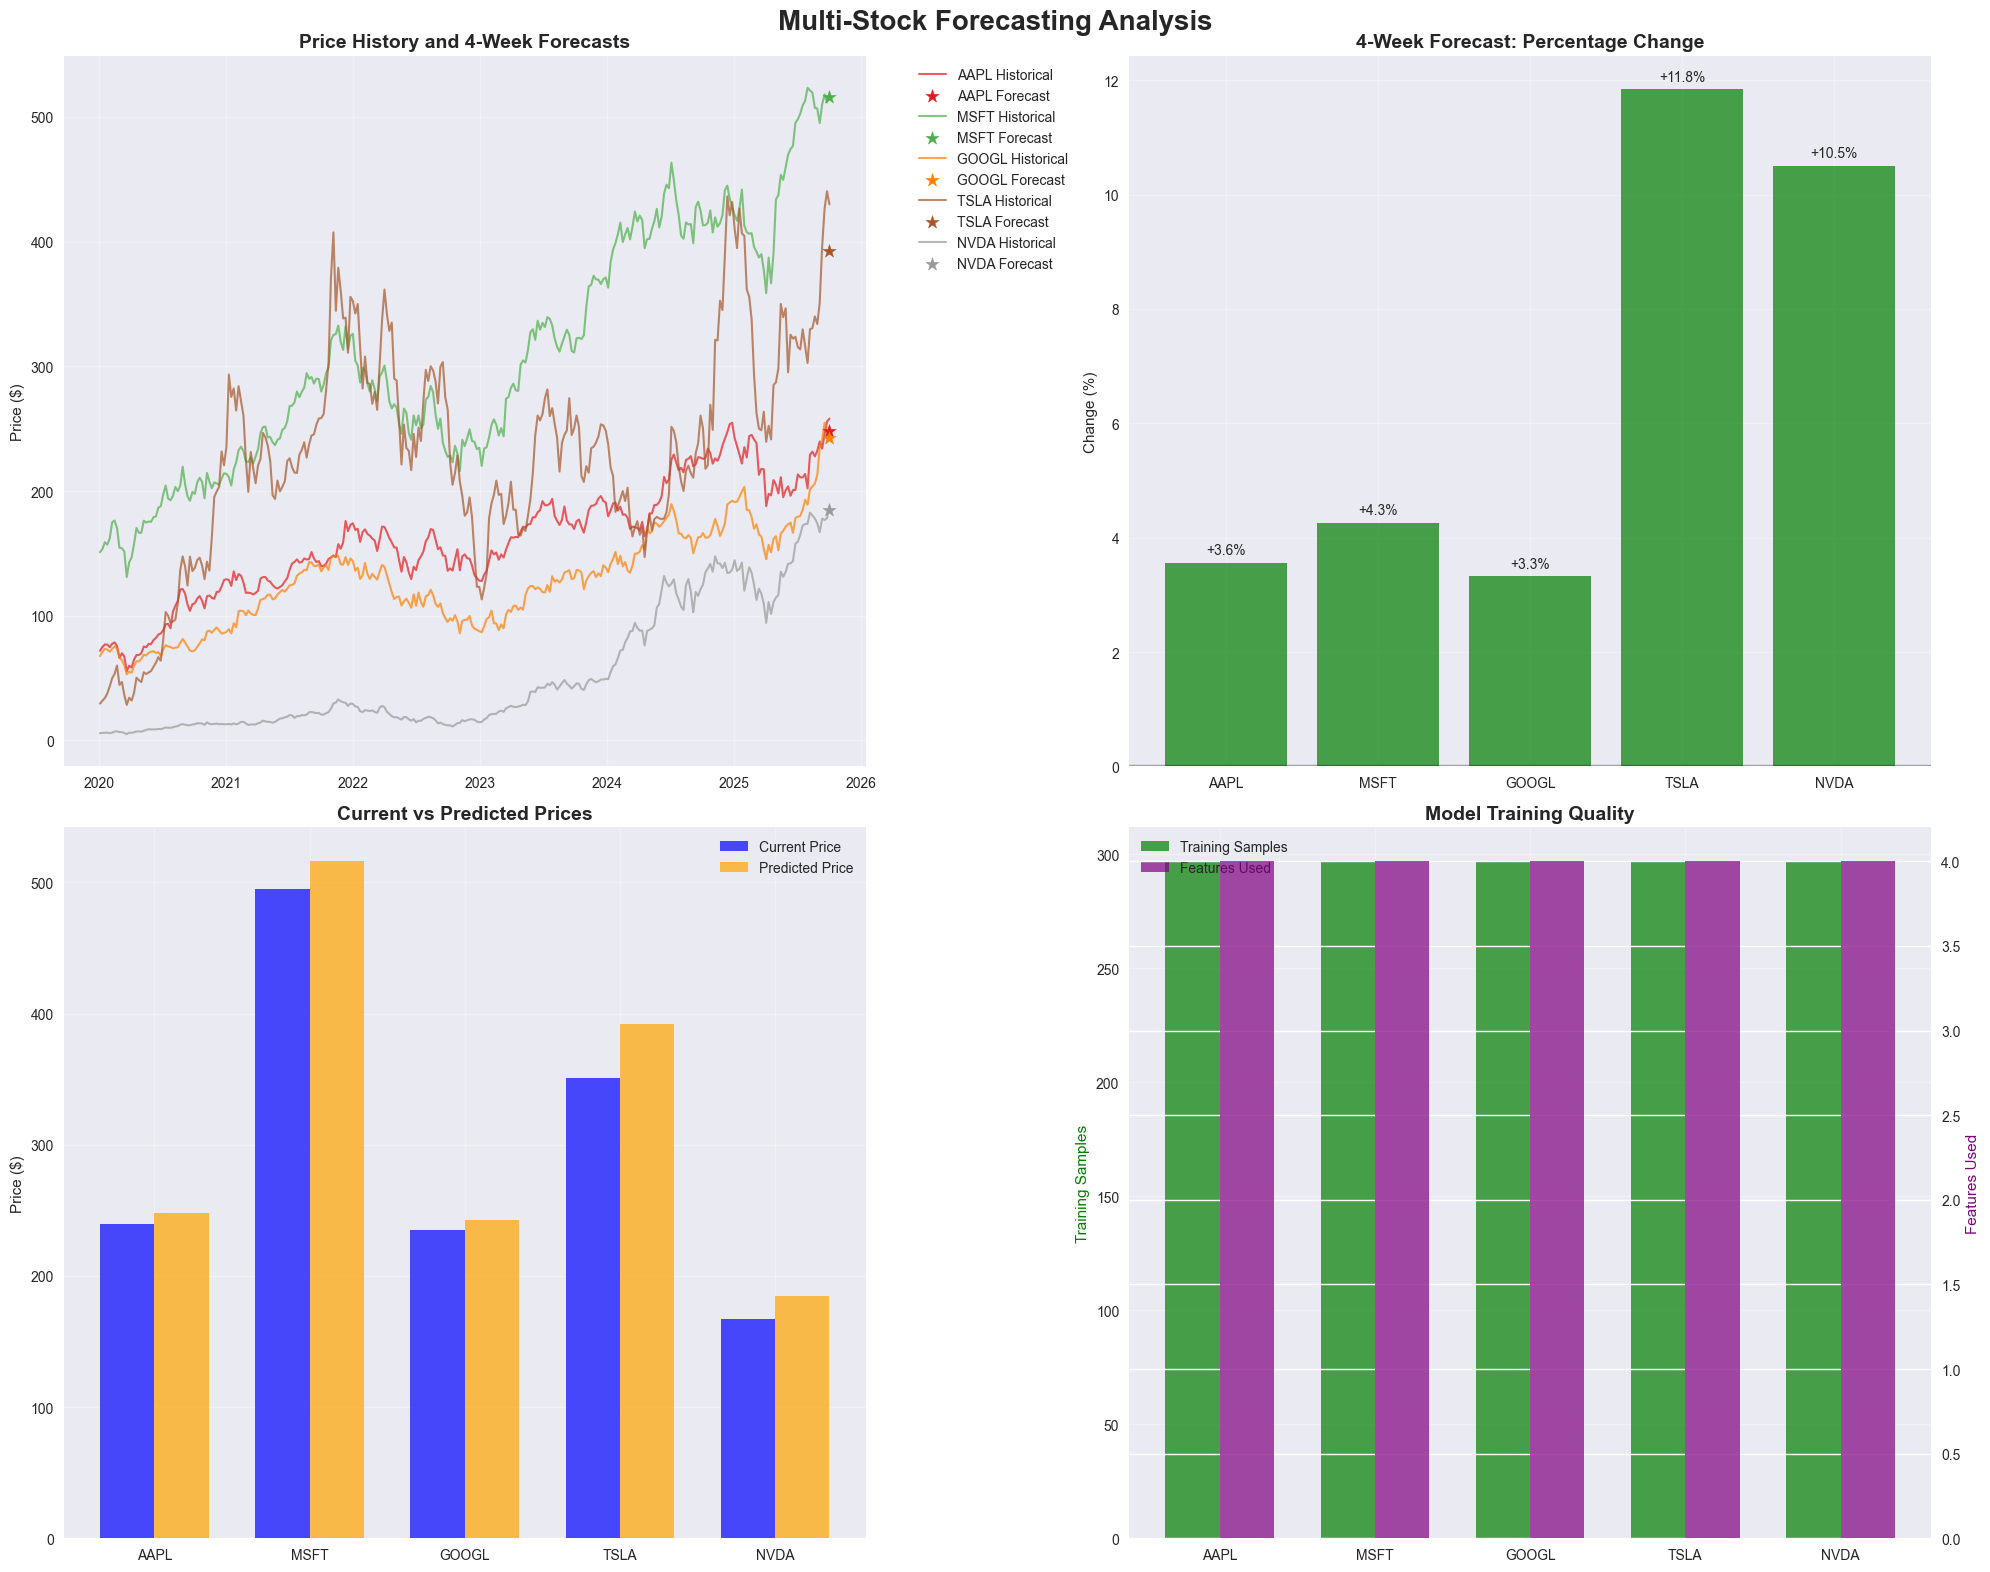

In [24]:
# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
fig.suptitle('Multi-Stock Forecasting Analysis', fontsize=20, fontweight='bold')

# 1. Price history and forecasts for all stocks
ax1 = axes[0, 0]
colors = plt.cm.Set1(np.linspace(0, 1, len(STOCK_SYMBOLS)))

for i, symbol in enumerate(STOCK_SYMBOLS):
    if symbol in weekly_data:
        data = weekly_data[symbol]
        ax1.plot(data.index, data['Close'], label=f'{symbol} Historical', 
                color=colors[i], alpha=0.7, linewidth=1.5)
        
        # Add forecast point
        if symbol in predictions:
            latest_date = data.index[-1]
            ax1.scatter(latest_date, predictions[symbol], 
                       color=colors[i], s=100, marker='*', 
                       label=f'{symbol} Forecast', zorder=5)

ax1.set_title('Price History and 4-Week Forecasts', fontsize=14, fontweight='bold')
ax1.set_ylabel('Price ($)')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(True, alpha=0.3)

# 2. Forecast percentage changes
ax2 = axes[0, 1]
if predictions:
    symbols_with_forecasts = [s for s in STOCK_SYMBOLS if s in training_summaries]
    changes_pct = [training_summaries[s]['price_change_pct'] for s in symbols_with_forecasts]
    colors_changes = ['green' if x > 0 else 'red' for x in changes_pct]
    
    bars = ax2.bar(symbols_with_forecasts, changes_pct, color=colors_changes, alpha=0.7)
    ax2.set_title('4-Week Forecast: Percentage Change', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Change (%)')
    ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    ax2.grid(True, alpha=0.3)
    
    # Add value labels on bars
    for bar, value in zip(bars, changes_pct):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + (0.1 if height > 0 else -0.3),
                f'{value:+.1f}%', ha='center', va='bottom' if height > 0 else 'top')

# 3. Current vs Predicted prices
ax3 = axes[1, 0]
if predictions:
    current_prices = [training_summaries[s]['current_price'] for s in symbols_with_forecasts]
    predicted_prices = [training_summaries[s]['predicted_price'] for s in symbols_with_forecasts]
    
    x = np.arange(len(symbols_with_forecasts))
    width = 0.35
    
    bars1 = ax3.bar(x - width/2, current_prices, width, label='Current Price', alpha=0.7, color='blue')
    bars2 = ax3.bar(x + width/2, predicted_prices, width, label='Predicted Price', alpha=0.7, color='orange')
    
    ax3.set_title('Current vs Predicted Prices', fontsize=14, fontweight='bold')
    ax3.set_ylabel('Price ($)')
    ax3.set_xticks(x)
    ax3.set_xticklabels(symbols_with_forecasts)
    ax3.legend()
    ax3.grid(True, alpha=0.3)

# 4. Training data quality
ax4 = axes[1, 1]
if predictions:
    training_samples = [training_summaries[s]['training_samples'] for s in symbols_with_forecasts]
    features_used = [training_summaries[s]['features_used'] for s in symbols_with_forecasts]
    
    ax4_twin = ax4.twinx()
    
    bars1 = ax4.bar(x - width/2, training_samples, width, label='Training Samples', alpha=0.7, color='green')
    bars2 = ax4_twin.bar(x + width/2, features_used, width, label='Features Used', alpha=0.7, color='purple')
    
    ax4.set_title('Model Training Quality', fontsize=14, fontweight='bold')
    ax4.set_ylabel('Training Samples', color='green')
    ax4_twin.set_ylabel('Features Used', color='purple')
    ax4.set_xticks(x)
    ax4.set_xticklabels(symbols_with_forecasts)
    
    # Add legends
    lines1, labels1 = ax4.get_legend_handles_labels()
    lines2, labels2 = ax4_twin.get_legend_handles_labels()
    ax4.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    
    ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 8. Next Steps and Recommendations

**Portfolio Analysis:**
- **Top Performers**: Focus on stocks with highest predicted returns
- **Risk Management**: Consider volatility and correlation between stocks
- **Diversification**: Balance between different sectors and market caps

**Model Improvements:**
1. **Hyperparameter Tuning**: Use `StandaloneBacktester` for model validation
2. **Ensemble Methods**: Combine multiple models for better predictions
3. **Market Regime Detection**: Adapt models based on market conditions
4. **Feature Selection**: Optimize feature sets for each stock individually

**Production Deployment:**
1. **Automated Updates**: Set up daily data refresh and model retraining
2. **Performance Monitoring**: Track prediction accuracy over time
3. **Alert System**: Notify on significant price movements or model changes
4. **Portfolio Integration**: Use forecasts in broader investment strategies

**Risk Considerations:**
- ⚠️ **Past Performance**: Historical data doesn't guarantee future results
- ⚠️ **Market Volatility**: External factors can significantly impact predictions
- ⚠️ **Model Limitations**: Machine learning models have inherent uncertainties
- ⚠️ **Diversification**: Don't rely on single stock predictions for investment decisions
